# 03 — Análise Exploratória de Dados

Gera estatísticas, nulos, correlações, histogramas, boxplots, heatmap, dispersão e insights escritos. Gráficos são exportados como PNG.

In [1]:
from pathlib import Path
import sys

# O notebook pode ser executado a partir da raiz ou da pasta notebooks/.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(f"Raiz do projeto: {ROOT}")

Raiz do projeto: /Users/djalma.rodrigues/projetos/99_Revisar/projeto-ia-ciencia-dados-2026


In [2]:
import json
import pandas as pd
from src.config import PROCESSED_DIR, TABLES_DIR
from src.eda import generate_eda_artifacts

insights = generate_eda_artifacts()
display(pd.Series(insights, name="valor"))

n_cursos                                                                 7723
media_target                                                        47.305757
mediana_target                                                      46.867742
desvio_target                                                        9.690339
limiar_target_treino                                                46.816228
prevalencia_classe_1                                                 0.501748
maior_taxa_nulos                                                          0.0
top_correlacoes_spearman    {'PROP_QE_I10_E': -0.6173426753923014, 'PROP_Q...
Name: valor, dtype: object

## Estatísticas, nulos e correlações

In [3]:
stats = pd.read_csv(TABLES_DIR / "estatisticas_descritivas.csv", index_col=0)
correlations = pd.read_csv(TABLES_DIR / "correlacoes_spearman_target.csv", index_col=0)
missing = pd.read_csv(TABLES_DIR / "proporcao_nulos.csv", index_col=0)
display(stats.loc[["NT_GER_MEDIA_CURSO", "N_INSCRITOS", "IDADE_MEDIA", "AVALIACAO_PROCESSO_MEDIA"]])
display(correlations.head(15))
display(missing.head(15))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
NT_GER_MEDIA_CURSO,7723.0,NaN,NaN,NaN,47.305757,9.690339,23.618182,40.197917,46.867742,53.694577,77.732000
N_INSCRITOS,7723.0,NaN,NaN,NaN,50.758514,90.215332,10.000000,21.000000,33.000000,56.000000,3754.000000
IDADE_MEDIA,7723.0,NaN,NaN,NaN,27.396998,3.297971,21.111111,25.152029,26.596330,28.736842,46.913043
AVALIACAO_PROCESSO_MEDIA,7723.0,NaN,NaN,NaN,5.193662,0.472153,3.198498,4.868039,5.190642,5.552734,6.000000


,spearman_com_nt_ger_media
PROP_QE_I10_E,-0.617343
PROP_QE_I10_A,0.571519
PROP_TURNO_4,-0.417769
PROP_QE_I23_B,-0.413855
PROP_QE_I25_E,0.375791
PROP_QE_I23_E,0.365191
PROP_QE_I26_B,-0.361674
IDADE_Q75,-0.356870
PROP_QE_I23_D,0.346671
PROP_QE_I25_C,-0.344174


,proporcao_nulos
CO_CURSO,0.0
PROP_QE_I23_C,0.0
PROP_QE_I23_A,0.0
TX_RESPOSTA_QE_I22,0.0
PROP_QE_I22_E,0.0
PROP_QE_I22_D,0.0
PROP_QE_I22_C,0.0
PROP_QE_I22_B,0.0
PROP_QE_I22_A,0.0
TX_RESPOSTA_QE_I21,0.0


## Gráficos exportados

eda_01_histograma_nt_ger_media.png


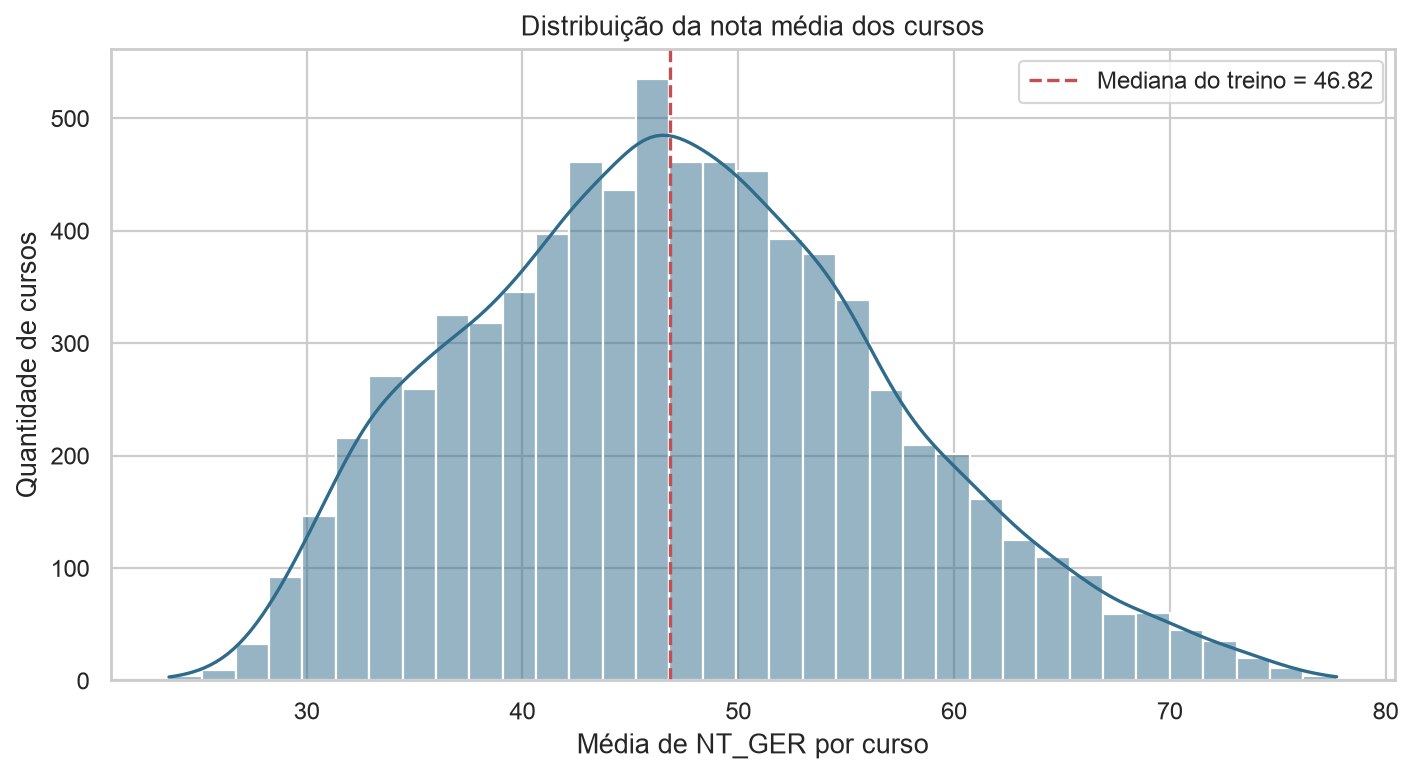

eda_02_boxplot_modalidade.png


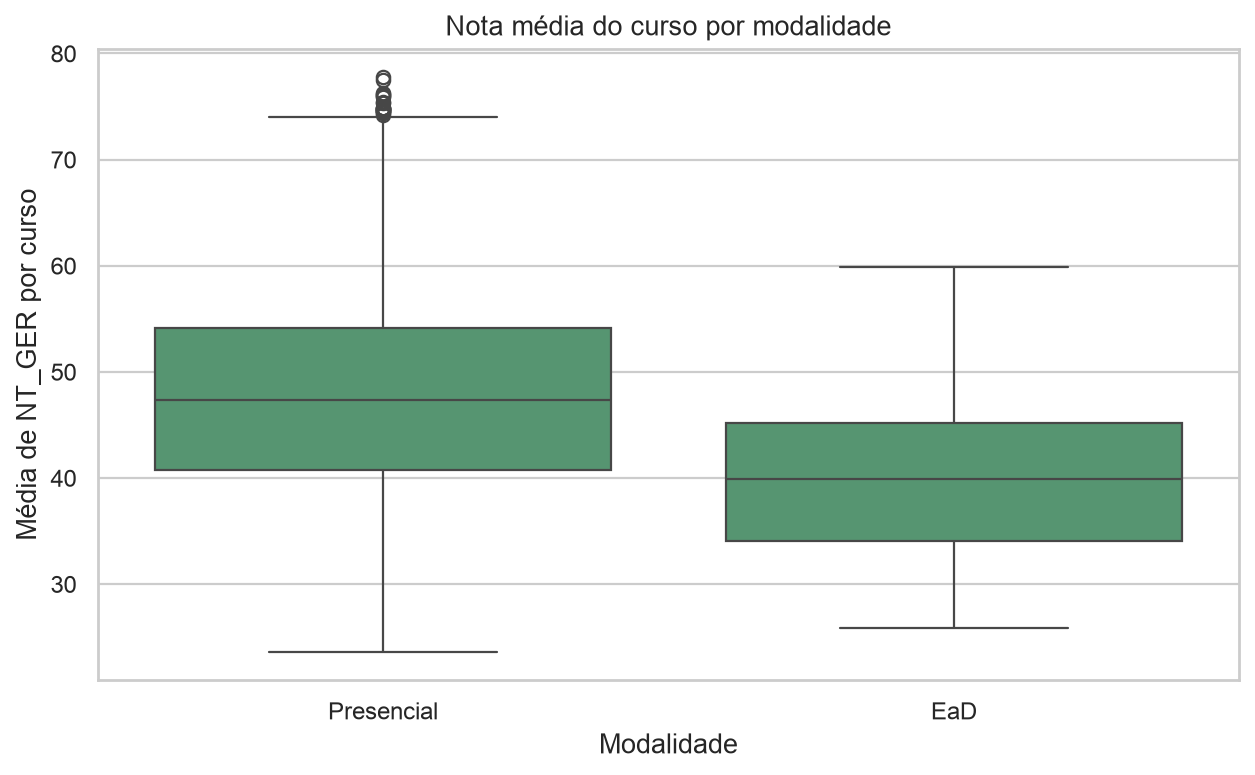

eda_03_heatmap_correlacoes.png


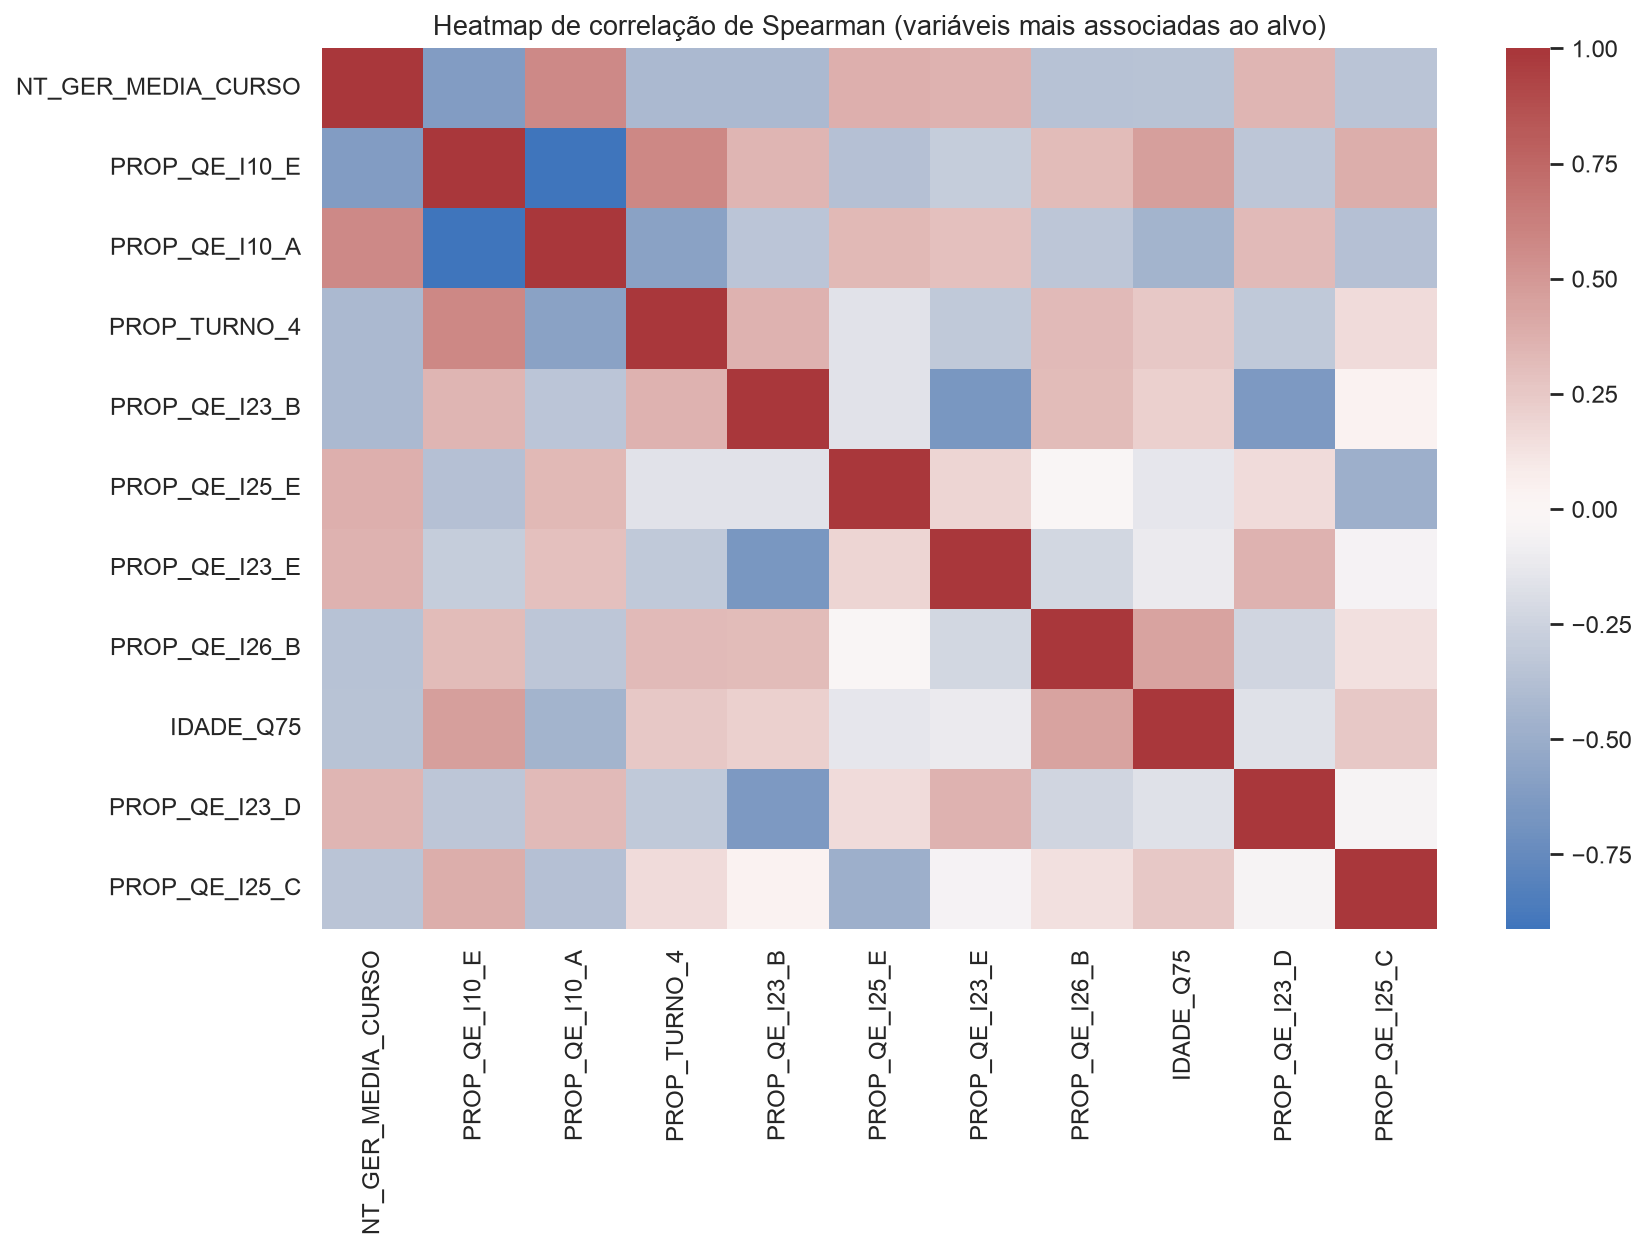

eda_04_distribuicao_classes.png


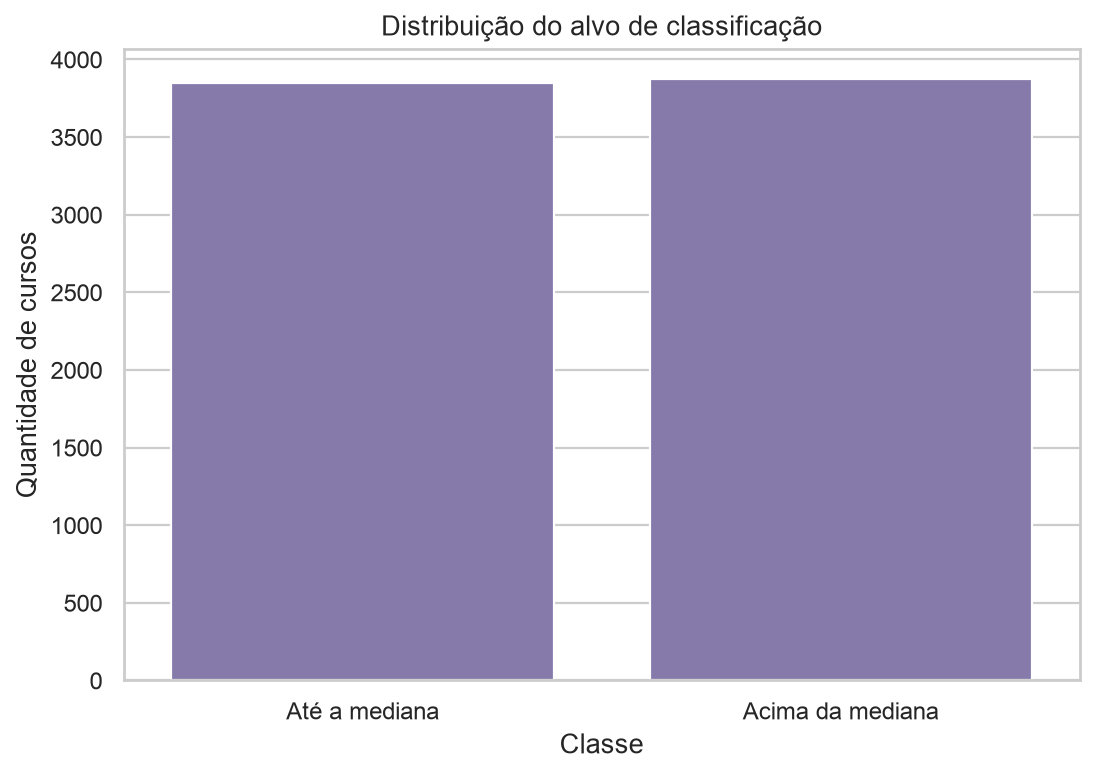

eda_05_nulos.png


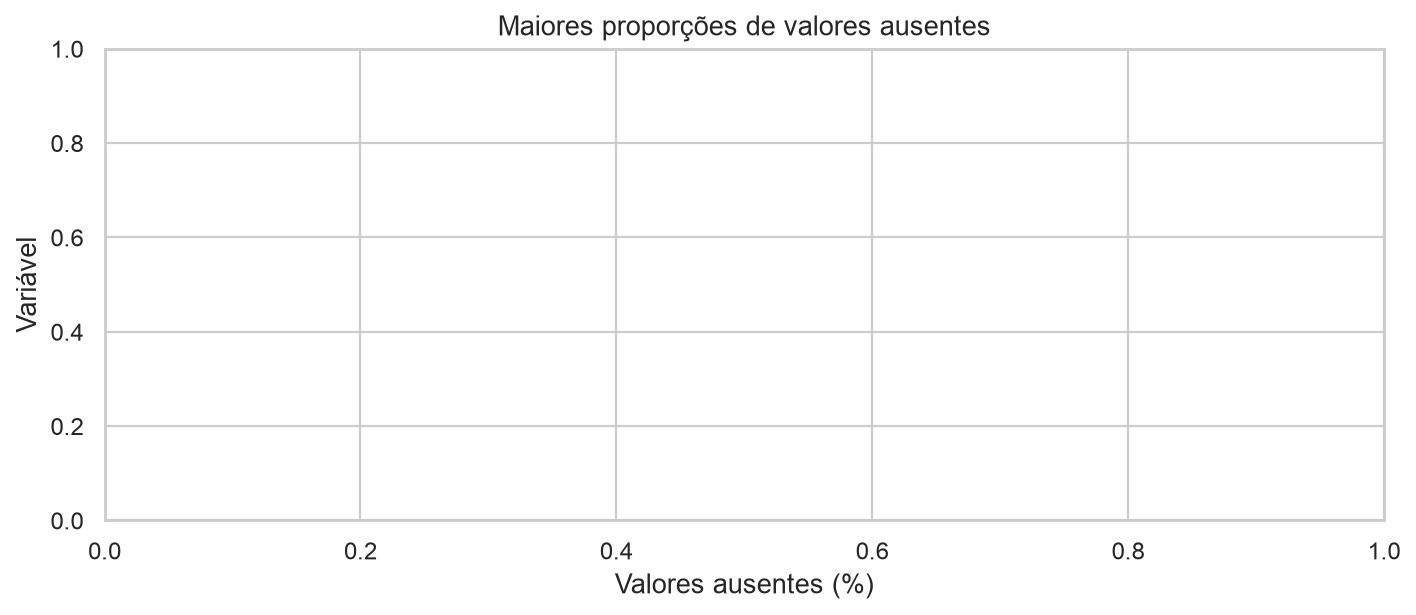

eda_06_boxplots_numericos.png


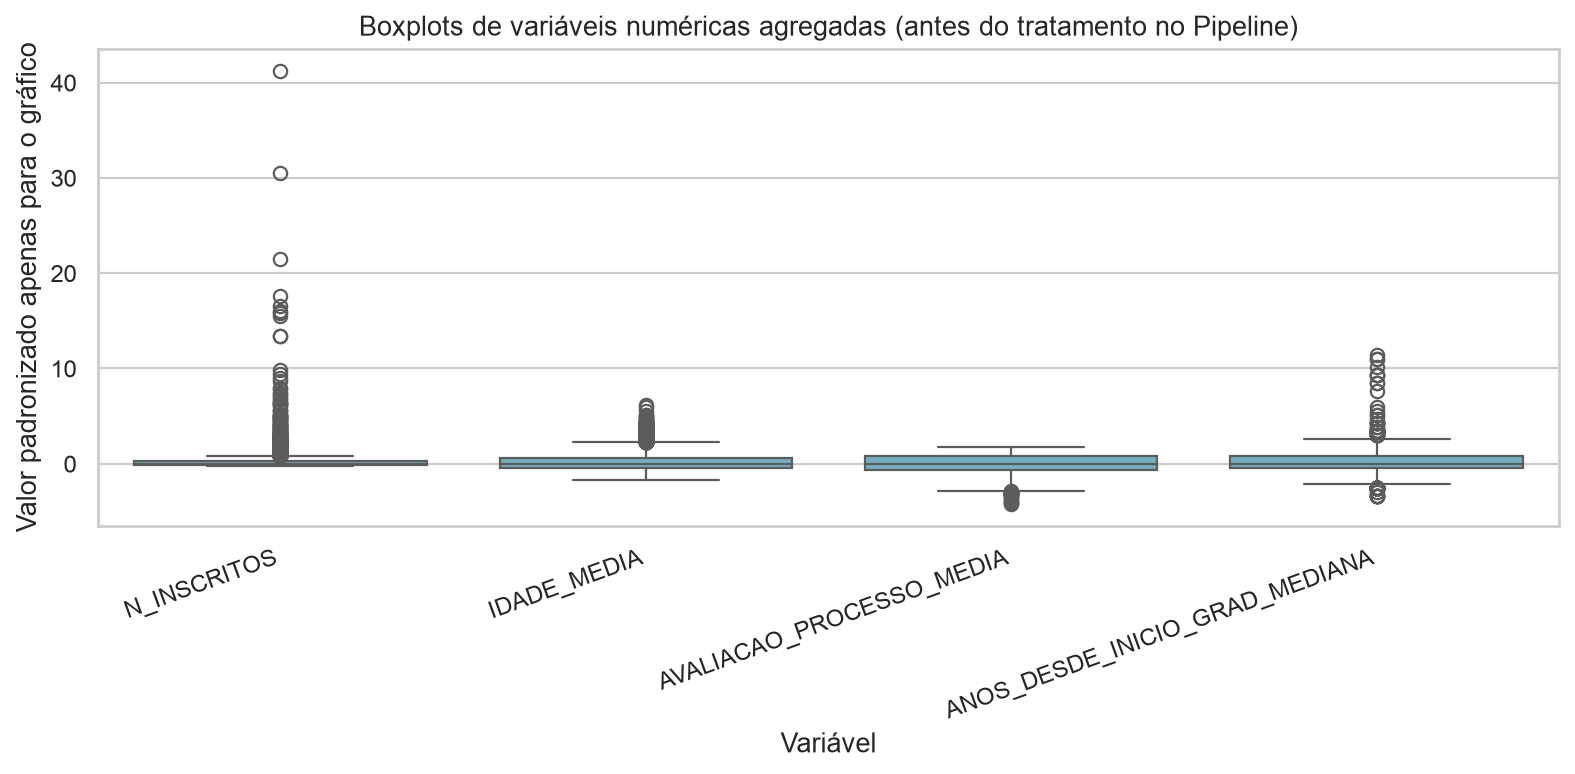

eda_07_dispersao_tamanho_nota.png


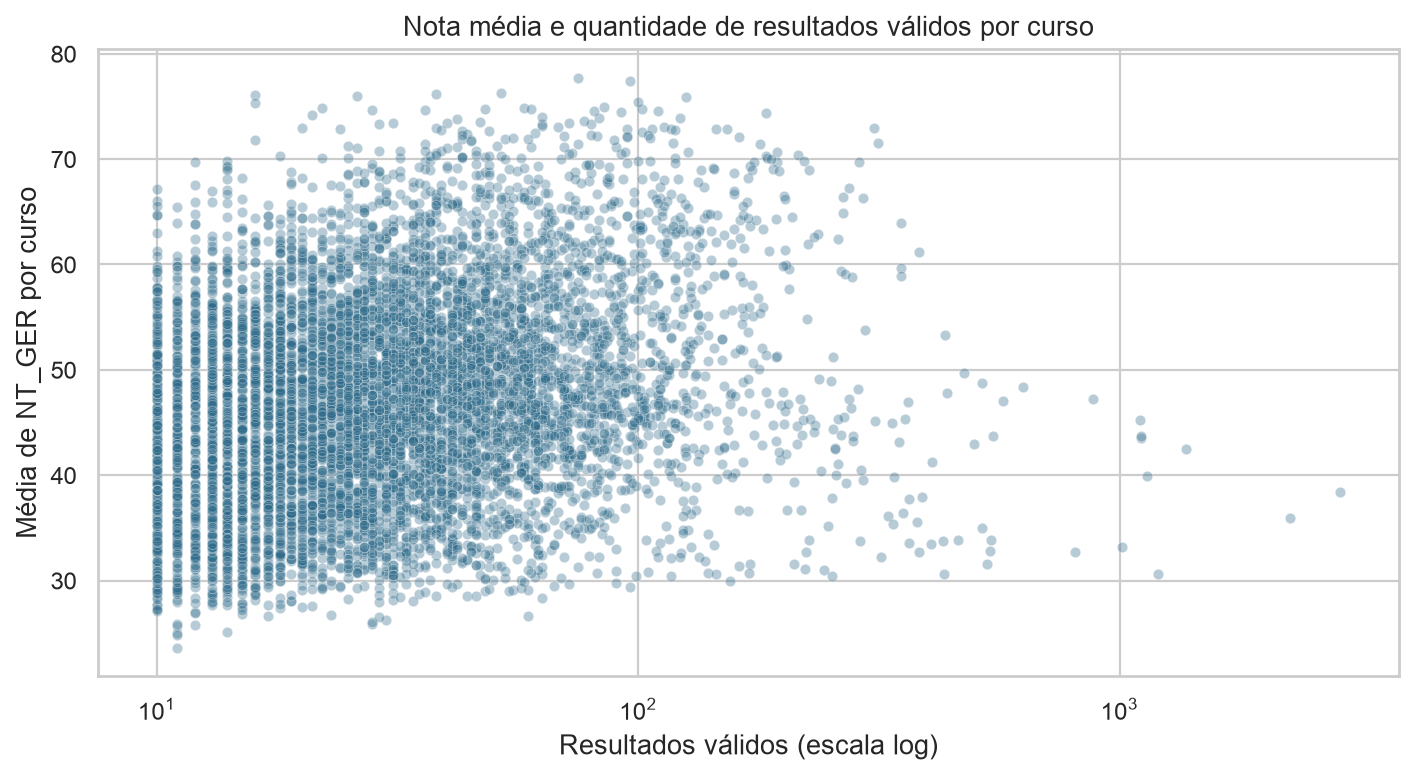

In [4]:
from IPython.display import Image, display
from src.config import FIGURES_DIR

for name in [
    "eda_01_histograma_nt_ger_media.png",
    "eda_02_boxplot_modalidade.png",
    "eda_03_heatmap_correlacoes.png",
    "eda_04_distribuicao_classes.png",
    "eda_05_nulos.png",
    "eda_06_boxplots_numericos.png",
    "eda_07_dispersao_tamanho_nota.png",
]:
    print(name)
    display(Image(filename=str(FIGURES_DIR / name), width=850))

## Insights escritos (gerados a partir dos valores observados)

In [5]:
top = insights["top_correlacoes_spearman"]
print(f"1. Foram analisados {insights['n_cursos']:,} cursos após o filtro de suporte mínimo.")
print(f"2. A média das notas médias dos cursos foi {insights['media_target']:.2f}, mediana {insights['mediana_target']:.2f} e desvio {insights['desvio_target']:.2f}.")
print(f"3. O alvo usa limiar {insights['limiar_target_treino']:.4f}, aprendido somente no treino; prevalência global da classe 1 = {insights['prevalencia_classe_1']:.2%}.")
print(f"4. A maior taxa de nulos entre as colunas modeladas/auxiliares foi {insights['maior_taxa_nulos']:.2%}; a imputação permanece dentro do Pipeline.")
print("5. Maiores associações de Spearman com o desfecho (não implicam causalidade):")
for feature, value in top.items():
    print(f"   - {feature}: rho={value:.3f}")
print("6. Diferenças por modalidade/região e importâncias do modelo devem ser interpretadas como associações agregadas, nunca como efeito causal ou avaliação individual.")

1. Foram analisados 7,723 cursos após o filtro de suporte mínimo.
2. A média das notas médias dos cursos foi 47.31, mediana 46.87 e desvio 9.69.
3. O alvo usa limiar 46.8162, aprendido somente no treino; prevalência global da classe 1 = 50.17%.
4. A maior taxa de nulos entre as colunas modeladas/auxiliares foi 0.00%; a imputação permanece dentro do Pipeline.
5. Maiores associações de Spearman com o desfecho (não implicam causalidade):
   - PROP_QE_I10_E: rho=-0.617
   - PROP_QE_I10_A: rho=0.572
   - PROP_TURNO_4: rho=-0.418
   - PROP_QE_I23_B: rho=-0.414
   - PROP_QE_I25_E: rho=0.376
6. Diferenças por modalidade/região e importâncias do modelo devem ser interpretadas como associações agregadas, nunca como efeito causal ou avaliação individual.
